Task 6. Thresholding and Morphology   

On your text-page photo, apply Otsu's thresholding, then use morphological closing to clean up the binary text. Show a before/after crop of one word, and note what kernel size worked and why a smaller or larger one didn't, given your image's resolution and font size. 

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [4]:
img = cv2.imread("raw_captures\Text.jpeg")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)


In [54]:
ret, otsu = cv2.threshold(
    gray,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

In [73]:
kernel = np.ones((2,2), np.uint8)

closed = cv2.morphologyEx(
    otsu,
    cv2.MORPH_CLOSE,
    kernel
)

In [74]:
crop_before = otsu[110:150, 110:220]
crop_after = closed[110:150, 110:220]

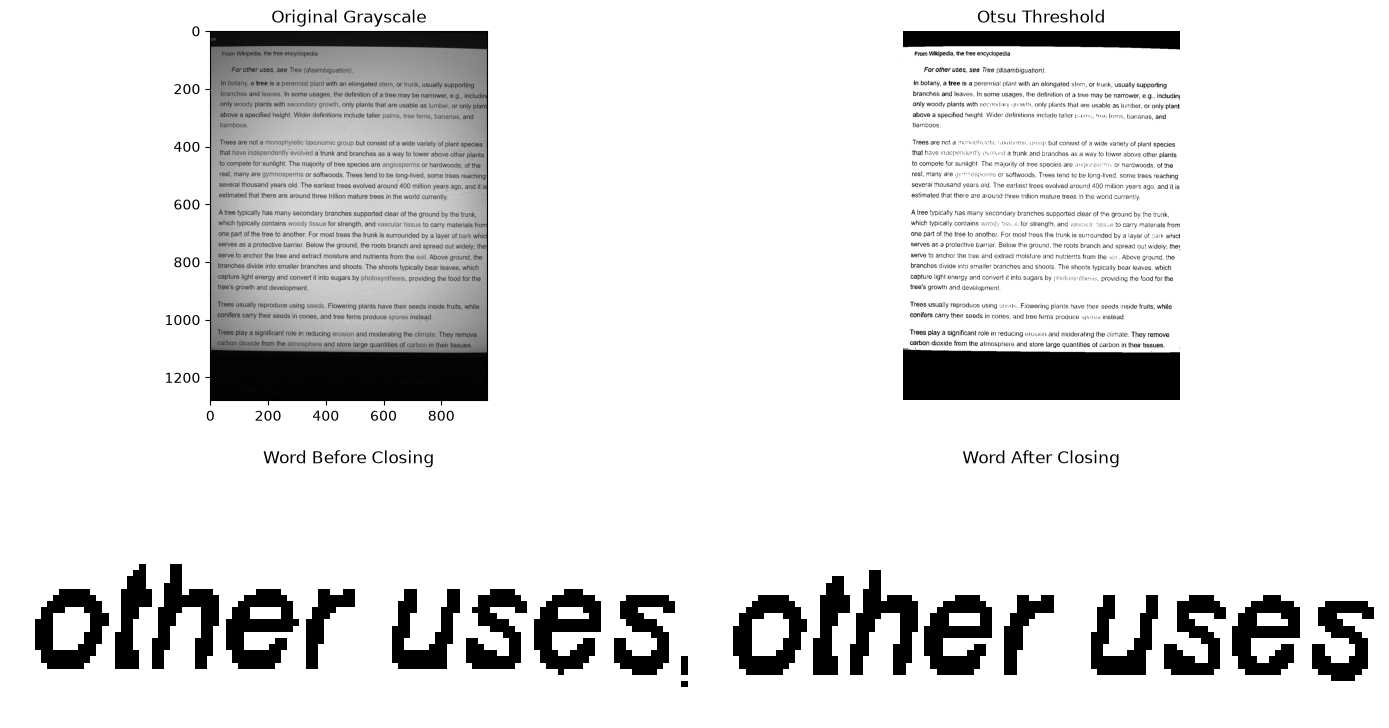

In [75]:

plt.figure(figsize=(14,8))

plt.subplot(2,2,1)
plt.imshow(gray, cmap='gray')
plt.title("Original Grayscale")


plt.subplot(2,2,2)
plt.imshow(otsu, cmap='gray')
plt.title("Otsu Threshold")
plt.axis("off")

plt.subplot(2,2,3)
plt.imshow(crop_before, cmap='gray')
plt.title("Word Before Closing")
plt.axis("off")

plt.subplot(2,2,4)
plt.imshow(crop_after, cmap='gray')
plt.title("Word After Closing")
plt.axis("off")

plt.tight_layout()
plt.show()

Otsu's thresholding successfully converted the text-page image into a clean binary image. I experimented with different kernel sizes for morphological closing. Larger kernels caused the text to become distorted, with some characters merging or losing their original shape. After reducing the kernel size to 2 × 2, the processed image became very similar to the thresholded image, with almost no visible changes. This indicates that the original text image was already clean and well-separated, so only a very small kernel was appropriate. A larger kernel was too aggressive for the image's resolution and font size, while the 2 × 2 kernel preserved the character shapes without introducing unwanted modifications.